# Atividade

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Newton

In [2]:
# Newton

xi = np.array([-7., -4.5, -1, 2.2, 8, 13.5, 21, 25])
yi = np.array([-12.5, 8, 0, -15.2, 25.4, 5, 42, 18])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

D = np.zeros((n, n))

D[:, 0] = yi.T

# Calcula todas as diferenças Divididas
for j in range(1, n):
    for i in range (j, n):
        D[i,j] = (D[i, j-1] - D[i-1, j-1]) / (xi[i] - xi[i-j])

c = np.diag(D)

y = np.ones(N) * c[0] 

xv = np.ones(N)

for j in range (1, n):
    xv *= (x - xi[j-1])
    y = y + c[j] * xv


# calculando f(6)
x_v = 6
y_v = c[0]

xv_v = 1

for j in range (1, n):
    xv_v = xv_v * (x_v - xi[j-1])
    y_v = y_v + c[j] * xv_v
print(f"newton : ponto {x_v} : {y_v}")

ponto_newton = y_v
x_newton = x
y_newton = y

newton : ponto 6 : 6.9328893681194055


## Spline

In [3]:
xi = np.array([-7., -4.5, -1, 2.2, 8, 13.5, 21, 25])
yi = np.array([-12.5, 8, 0, -15.2, 25.4, 5, 42, 18])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

m = n - 1

h = np.zeros(n-1)

for i in range (0, n-1):
    h[i] = xi[i+1] - xi[i]


a = yi
A = np.zeros((n, n))
r = np.zeros(n)

A[0,0] = 1
A[n-1,n-1] = 1

for j in range(1, n-1):
    A[j, j-1] = h[j-1]
    A[j, j] = 2 * h[j-1] + h[j]
    A[j, j+1] = h[j]
    r[j] = 3 * ((a[j+1] - a[j]) / h[j] - (a[j] - a[j-1]) / h[j-1])

c = np.linalg.solve(A, r)

d = np.zeros(m)

b = np.zeros(m)

for j in range (0, m):
    d[j] = (c[j+1] - c[j]) / (3 * h[j])
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j+1])


y = np.zeros(N)

for k in range (0, N):
    id = m
    for j in range (0, m):
        if x[k] <= xi[j+1]:
            id = j
            break
    t = x[k] - xi[id]
    y[k] = a[id] + b[id] * t + c[id] * t**2 + d[id] * t ** 3


# calculando f(6)

ponto = 6

n = len(x)

m = n - 1 

h = np.zeros(m)

for i in range(m):
    h[i] = x[i + 1] - x[i]

a = y

A = np.zeros((n, n))

r = np.zeros(n)

A[0, 0] = 1
A[n - 1, n - 1] = 1

for j in range(1, n - 1):
    A[j, j - 1] = h[j - 1]
    A[j, j] = 2 * (h[j - 1] + h[j])
    A[j, j + 1] = h[j]
    r[j] = 3 * (((a[j+1] - a[j]) / h[j]) - ((a[j] - a[j-1]) / h[j-1]))

c = np.linalg.solve(A, r)

idx = 0

for j in range(0, m):
    if ponto <= x[j + 1]:
        idx = j
        break

d = (c[idx + 1] - c[idx]) / (3 * h[idx])

b = ((a[idx + 1] - a[idx]) / h[idx]) - ((h[idx] / 3) * (2 * c[idx] + c[idx + 1]))

t = ponto - x[idx]

ponto_spline = a[idx] + b * t + c[idx] * (t**2) + d * (t**3)

print(f"spline cúbico : ponto {ponto} : {ponto_spline}")


x_spline = x
y_spline = y

spline cúbico : ponto 6 : 13.711702505171205


## Interpolação de Hermite

In [4]:
def hermite(dyi):
    xi = np.array([-7., -4.5, -1, 2.2, 8, 13.5, 21, 25])
    yi = np.array([-12.5, 8, 0, -15.2, 25.4, 5, 42, 18])

    n = len(xi)

    N = 100

    x = np.linspace(xi[0], xi[n - 1], N)


    L = np.ones((n, N))

    dL = np.zeros(n)

    for i in range (0, n):
        for j in range (0, n):
            if i != j:
                L[i, :] *= (x - xi[j]) / (xi[i] - xi[j])

    for i in range (0, n):
        for k in range (0, n):
            if k != i:
                dL[i] += 1 / (xi[i] - xi[k])

    h = np.zeros((n, N))
    h_til = np.zeros((n, N))

    for i in range (0, n):
        h[i, :] = (1 - 2 * (x - xi[i]) * dL[i]) * L[i, :] ** 2

        h_til[i, :] = (x - xi[i]) * L[i, :] ** 2


    y = yi @ h + dyi @ h_til

    x_hermite = x
    y_hermite = y

    # calculando f(6)
    ponto = 6

    L = np.ones(n)
    for i in range(n):
        for j in range(n):
            if i != j:
                L[i] *= (ponto - xi[j]) / (xi[i] - xi[j])

    
    dL = np.zeros(n)
    for i in range(n):
        for k in range(n):
            if k != i:
                dL[i] += 1 / (xi[i] - xi[k])

    
    h = np.zeros(n)
    h_til = np.zeros(n)
    for i in range(n):
        h[i] = (1 - 2 * (ponto - xi[i]) * dL[i]) * (L[i] ** 2)
        h_til[i] = (ponto - xi[i]) * (L[i] ** 2)

    ponto_hermite = yi @ h + dyi @ h_til


    return x_hermite, y_hermite, ponto_hermite

## A

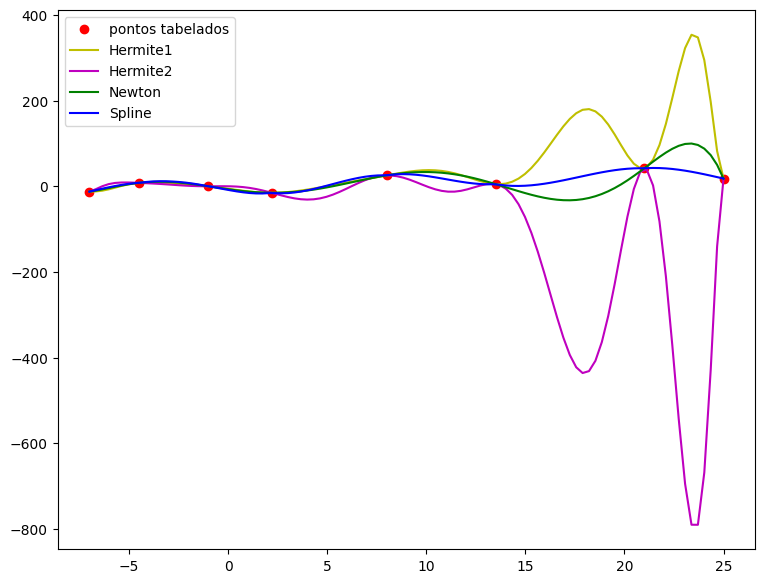

In [5]:
dyi = np.array([1.5, 4.2, -5, 0, 8.5, -3.2, 12, -1.5])
x_hermite1, y_hermite1, ponto_hermite1 = hermite(dyi)

dyi = np.array([10., -2, 0, -12.5, 1, -8, 2.5, -20])
x_hermite2, y_hermite2, ponto_hermite2 = hermite(dyi)

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='pontos tabelados')
plt.plot(x_hermite1, y_hermite1, 'y-', label='Hermite1')
plt.plot(x_hermite2, y_hermite2, 'm-', label='Hermite2')
plt.plot(x_newton, y_newton, 'g-', label='Newton')
plt.plot(x_spline, y_spline, 'b-', label='Spline')
plt.legend()
plt.show()

## B

In [6]:
print(f"Newton ({ponto}) : {ponto_newton}")
print(f"Spline ({ponto}) : {ponto_spline}")
print(f"Hermite ({ponto}) : {ponto_hermite1}")
print(f"Hermite ({ponto}) : {ponto_hermite2}")

Newton (6) : 6.9328893681194055
Spline (6) : 13.711702505171205
Hermite (6) : 8.723310416901858
Hermite (6) : -5.000166733855572
